Index(['Date', 'Value'], dtype='object')

Oil Risk Metrics
                 Metric       Value
0        Volatility (%)    9.050632
1  Maximum Increase (%)  132.521908
2  Maximum Decrease (%)  -54.149921


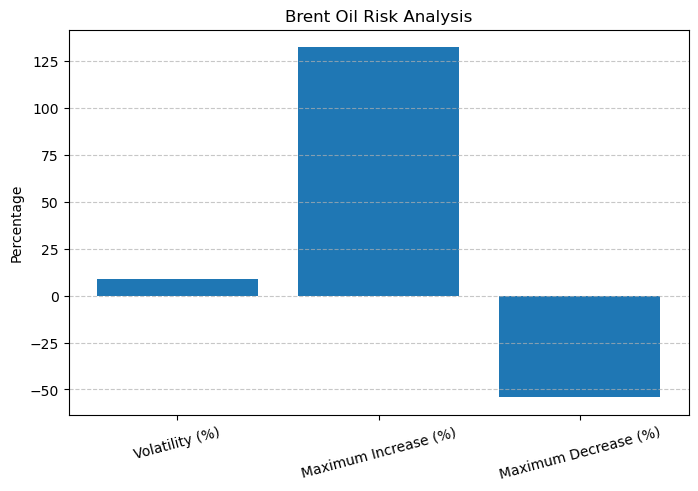

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Brent Oil dataset
oil = pd.read_csv("Brent Oil.csv")

# Display columns
print(oil.columns)

# Rename columns if required
oil = oil.rename(columns={
    oil.columns[0]: "Date",
    oil.columns[1]: "Price"
})

# Convert data types
oil["Date"] = pd.to_datetime(oil["Date"], errors="coerce")
oil["Price"] = pd.to_numeric(oil["Price"], errors="coerce")

# Calculate percentage change
oil["Pct_Change"] = oil["Price"].pct_change() * 100

# Risk metrics
volatility = oil["Pct_Change"].std()
max_increase = oil["Pct_Change"].max()
max_decrease = oil["Pct_Change"].min()

# Create summary table
risk_table = pd.DataFrame({
    "Metric": ["Volatility (%)", "Maximum Increase (%)", "Maximum Decrease (%)"],
    "Value": [volatility, max_increase, max_decrease]
})

print("\nOil Risk Metrics")
print(risk_table)

# Bar Chart
plt.figure(figsize=(8,5))
plt.bar(risk_table["Metric"], risk_table["Value"])
plt.title("Brent Oil Risk Analysis")
plt.ylabel("Percentage")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()